Comparar Resultados

Comparar Max Height


📊 Comparando: mw_8.1/02083
🌊 HySEA max: 2.863 m | EasyWave max: 4.471 m


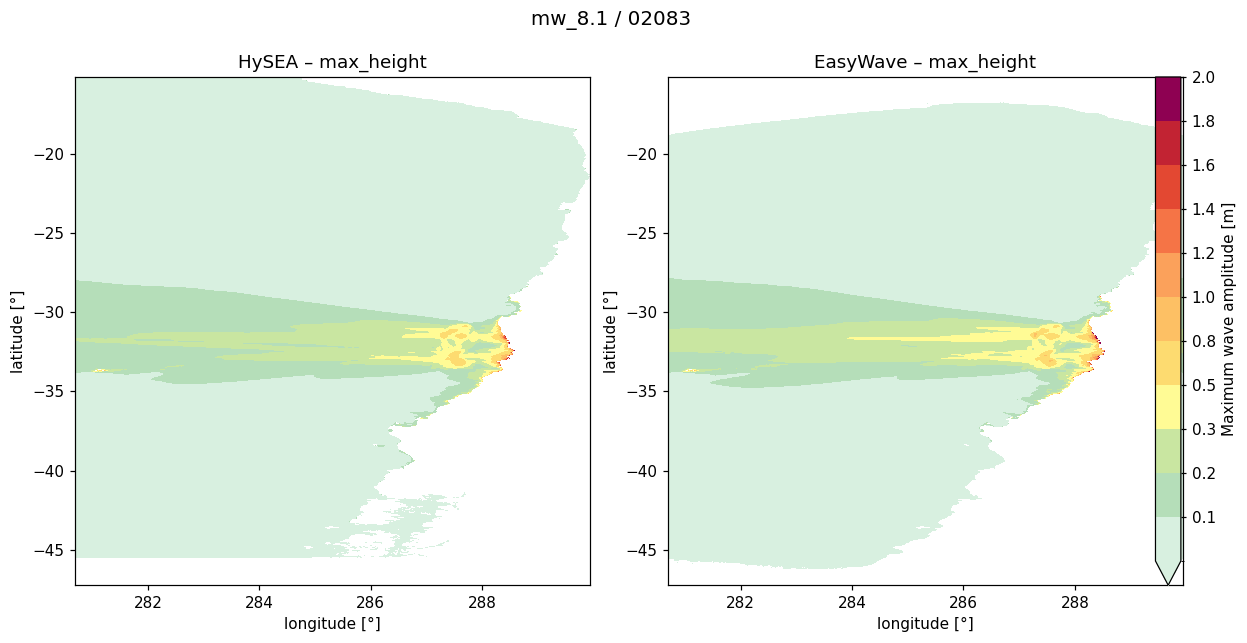


📊 Comparando: mw_8.3/03529
🌊 HySEA max: 3.124 m | EasyWave max: 4.038 m


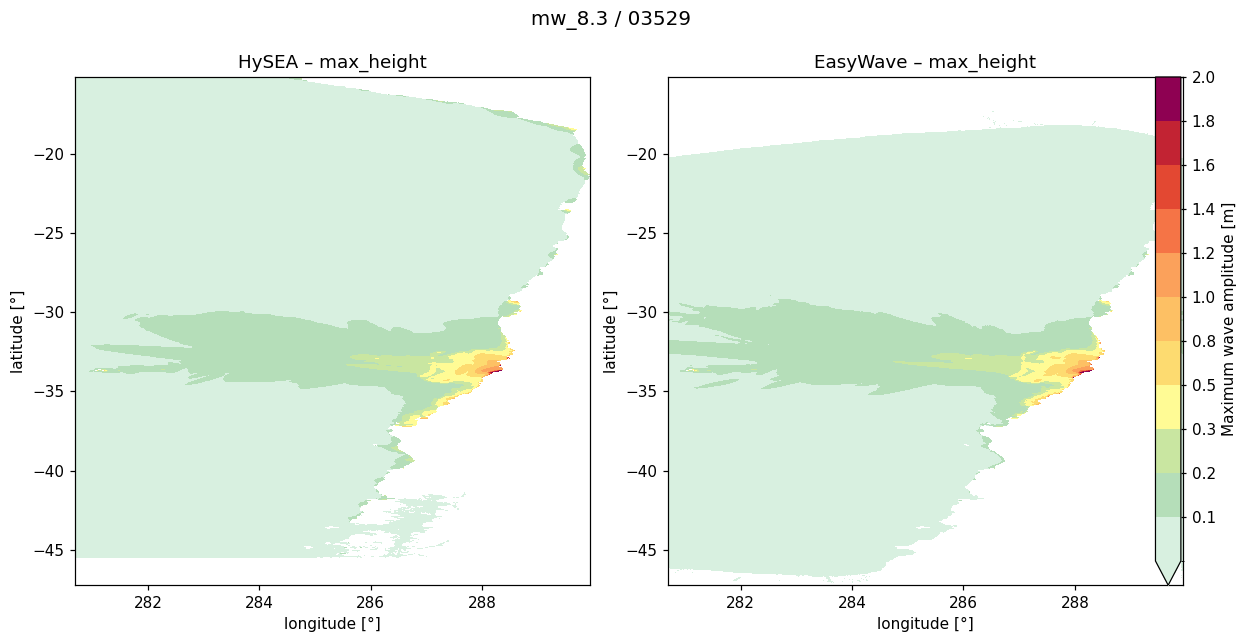


✅ Todas las comparaciones completadas.


In [4]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import numpy as np
from pathlib import Path

# --------------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------------
base_path = Path("Datos/simulaciones-tsunami-hysea")

# Paleta personalizada (misma que usaste antes)
colors = [
    "#d8f0e0", "#a5d6a7", "#ffff99", "#fdd266",
    "#fdae61", "#f46d43", "#d73027", "#8e0152",
]
cmap = LinearSegmentedColormap.from_list("tsunami_like", colors, N=256).copy()
cmap.set_under("white")
cmap.set_bad("white")

levels = [1e-6, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2]
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# --------------------------------------------------------
# COMPARACIÓN
# --------------------------------------------------------
for mw_folder in sorted(base_path.glob("mw_*")):
    for sim_folder in sorted(mw_folder.glob("*")):
        level01_file = sim_folder / "level01.nc"
        easywave_file = sim_folder / "resultado_easywave.nc"

        if not (level01_file.exists() and easywave_file.exists()):
            continue

        print(f"\n📊 Comparando: {mw_folder.name}/{sim_folder.name}")

        try:
            ds_hysea = xr.open_dataset(level01_file)
            ds_easy = xr.open_dataset(easywave_file)
        except Exception as e:
            print(f"⚠️ Error al abrir archivos: {e}")
            continue

        if "max_height" not in ds_hysea or "max_height" not in ds_easy:
            print("⚠️ Variable 'max_height' no encontrada.")
            continue

        da_hysea = ds_hysea["max_height"].clip(min=0)
        da_easy = ds_easy["max_height"].clip(min=0)
         # Límites dinámicos tomados desde EasyWave
        lon_min = float(da_easy.lon.min())
        lon_max = float(da_easy.lon.max())
        lat_min = float(da_easy.lat.min())
        lat_max = float(da_easy.lat.max())   

        # Margen opcional (grados)
        pad = 0.0
        xlim = (lon_min - pad, lon_max + pad)
        ylim = (lat_min - pad, lat_max + pad)    

        # Valores máximos
        max_hysea = float(da_hysea.max().values)
        max_easy = float(da_easy.max().values)
        print(f"🌊 HySEA max: {max_hysea:.3f} m | EasyWave max: {max_easy:.3f} m")

        # Gráficos
        fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=110)

        da_hysea.plot(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
        axes[0].set_title("HySEA – max_height")
        axes[0].set_xlabel("longitude [°]")
        axes[0].set_ylabel("latitude [°]")
        axes[0].set_xlim(*xlim)
        axes[0].set_ylim(*ylim)

        da_easy.plot(ax=axes[1], cmap=cmap, norm=norm, add_colorbar=False)
        axes[1].set_title("EasyWave – max_height")
        axes[1].set_xlabel("longitude [°]")
        axes[1].set_ylabel("latitude [°]")
        axes[1].set_xlim(*xlim)
        axes[1].set_ylim(*ylim)

        cbar = fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            ax=axes,
            fraction=0.025,
            pad=0.04,
            label="Maximum wave amplitude [m]",
            extend="min",
            ticks=levels[1:],
        )

        plt.suptitle(f"{mw_folder.name} / {sim_folder.name}", fontsize=13)
        plt.subplots_adjust(wspace=0.15, top=0.88)
        plt.show()

print("\n✅ Todas las comparaciones completadas.")


Comparar Eta

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import numpy as np
from pathlib import Path

# --------------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------------
base_path = Path("Datos/simulaciones-tsunami-hysea")

colors = [
    "#d8f0e0", "#a5d6a7", "#ffff99", "#fdd266",
    "#fdae61", "#f46d43", "#d73027", "#8e0152",
]
cmap = LinearSegmentedColormap.from_list("tsunami_like", colors, N=256).copy()
cmap.set_under("white")
cmap.set_bad("white")

levels = [1e-6, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# --------------------------------------------------------
# PROCESAR SIMULACIONES
# --------------------------------------------------------
for mw_folder in sorted(base_path.glob("mw_*")):
    for sim_folder in sorted(mw_folder.glob("*")):
        level01_file = sim_folder / "level01.nc"
        easywave_file = sim_folder / "resultado_easywave.nc"

        if not (level01_file.exists() and easywave_file.exists()):
            continue

        print(f"\n📈 Analizando ETA: {mw_folder.name}/{sim_folder.name}")

        ds_hysea = xr.open_dataset(level01_file)
        ds_easy = xr.open_dataset(easywave_file)

        # Verificar existencia de variable eta
        if "eta" not in ds_hysea or "eta" not in ds_easy:
            print("⚠️ No se encontró la variable 'eta' en uno de los archivos.")
            continue

        eta_hysea = ds_hysea["eta"]
        eta_easy = ds_easy["eta"]

        # Mostrar info estadística
        print(f"HySEA eta → shape: {eta_hysea.shape}, time: {eta_hysea['time'].size}")
        print(f"   min: {float(eta_hysea.min()):.3f}, max: {float(eta_hysea.max()):.3f}, mean: {float(eta_hysea.mean()):.3f}")
        print(f"EasyWave eta → shape: {eta_easy.shape}, time: {eta_easy['time'].size}")
        print(f"   min: {float(eta_easy.min()):.3f}, max: {float(eta_easy.max()):.3f}, mean: {float(eta_easy.mean()):.3f}")

        # Elegir un tiempo de comparación
        common_times = np.intersect1d(eta_hysea["time"], eta_easy["time"])
        if len(common_times) == 0:
            print("⚠️ No hay tiempos comunes entre ambos archivos.")
            continue

        t = common_times[len(common_times)//2]  # tiempo medio
        print(f"🕒 Mostrando comparación en t = {float(t):.1f} s")

        da_h = eta_hysea.sel(time=t).clip(min=0)
        da_e = eta_easy.sel(time=t).clip(min=0)

        # Graficar
        fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=110)

        da_h.plot(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
        axes[0].set_title(f"HySEA – eta (t={float(t):.0f}s)")

        da_e.plot(ax=axes[1], cmap=cmap, norm=norm, add_colorbar=False)
        axes[1].set_title(f"EasyWave – eta (t={float(t):.0f}s)")

        fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            ax=axes,
            fraction=0.025,
            pad=0.04,
            label="Wave height [m]",
            extend="min",
            ticks=levels[1:],
        )

        plt.suptitle(f"{mw_folder.name} / {sim_folder.name}", fontsize=13)
        plt.subplots_adjust(wspace=0.15, top=0.88)
        plt.show()



📈 Analizando ETA: mw_8.1/02083
⚠️ No se encontró la variable 'eta' en uno de los archivos.

📈 Analizando ETA: mw_8.3/03529
⚠️ No se encontró la variable 'eta' en uno de los archivos.


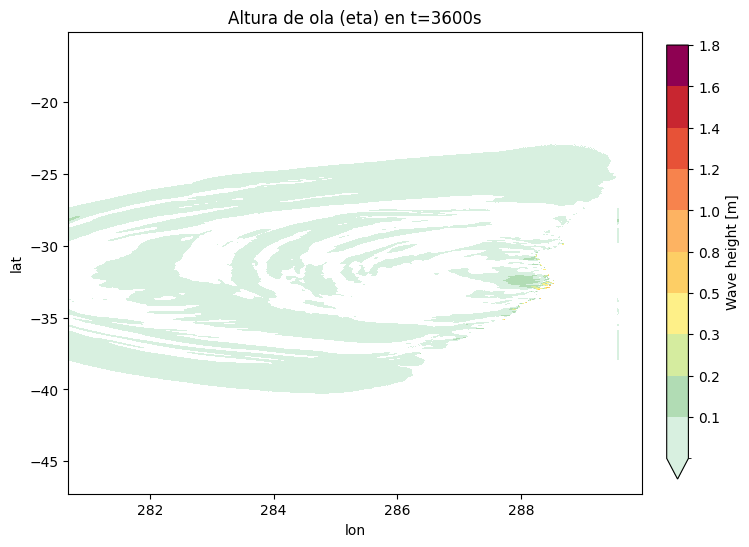

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

# Paleta tipo ejemplo: verde→amarillo→naranja→rojo→magenta
colors = [
    "#d8f0e0",  # verde muy claro
    "#a5d6a7",  # verde
    "#ffff99",  # amarillo
    "#fdd266",  # amarillo-naranja
    "#fdae61",  # naranja
    "#f46d43",  # naranja-rojo
    "#d73027",  # rojo
    "#8e0152",  # magenta
]
cmap = LinearSegmentedColormap.from_list("tsunami_like", colors, N=256).copy()
cmap.set_under("white")   # 0 en blanco
cmap.set_bad("white")

# Niveles discretos
levels = [1e-6, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Graficar
plt.figure(figsize=(8,6))
mappable = frame.plot(cmap=cmap, norm=norm, add_colorbar=False)  # add_colorbar=False evita doble barra
plt.title(f"Altura de ola (eta) en t={t}s")

# Colorbar personalizada
plt.colorbar(
    mappable=mappable,
    fraction=0.035,
    pad=0.04,
    label="Wave height [m]",
    extend="min",
    ticks=levels[1:]
)

plt.show()
